# MAIN - Betaflight Controller Analysis Main File

Betaflight Controller Tuning Analysis Script  
**Purpose:** Analyzes flight logs and tunes PID controllers for a quadcopter

**Author:** Janick Dort, Yuri Bianchi, Dario Jurietti  
**Supervisors:** Michael Peter, Ruprecht Altenburger  
**Date:** 28.02.2026

In [14]:
%matplotlib inline

import numpy as np
from pathlib import Path

from py_lib.flight_data import FlightData
from py_lib.flight_analyzer import FlightAnalyzer
from py_lib.gyro_ctrl_tuning import GyroCtrlTuning
from py_lib.plot_utils import PlotUtils
from py_lib.pidtuninglib import header_info
import matplotlib.pyplot as plt

## General Setup

In [15]:
# Show legends
do_insert_legends = True

# Create plotter
plotter = PlotUtils(do_insert_legends)

## Loading Data

In [16]:
# Path to Log file
log_folder = 'logs'
flight_folder = '20260417'
log_name = '6_inch_drone.TXT.csv'
file_path = Path(log_folder) / flight_folder / log_name

print(f"\nLoading flight log: {file_path}")

# Load flight data
df = FlightData(str(file_path))
df = df.get_data()

print(f"Data loaded: {len(df.time)} samples, Ts_log = {df.Ts_log*1000:.3f} ms")


Loading flight log: logs/20260417/6_inch_drone.TXT.csv
Loading flight data...
Loaded from cache in 0.027s
Data loaded: 400848 samples, Ts_log = 0.500 ms


## Plot Flight Data

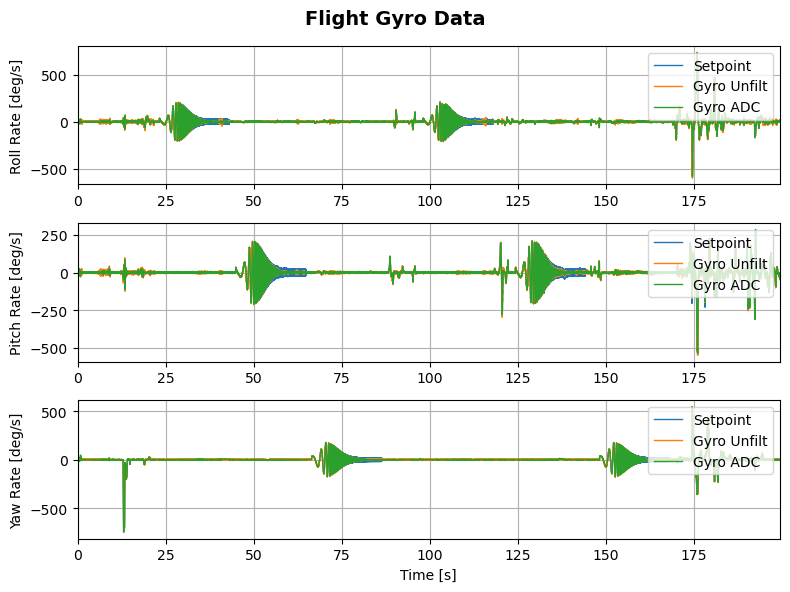

In [17]:
roll, pitch, yaw = 0, 1, 2

# Group 1: Custom labels for Flight Data Plot
group1 = [
    {
        'idx': np.array([df.ind.setpoint[roll], df.ind.gyroUnfilt[roll], df.ind.gyroADC[roll]]),
        'ylabel': 'Roll Rate [deg/s]',
        'legend': ['Setpoint', 'Gyro Unfilt', 'Gyro ADC']
    },
    {
        'idx': np.array([df.ind.setpoint[pitch], df.ind.gyroUnfilt[pitch], df.ind.gyroADC[pitch]]),
        'ylabel': 'Pitch Rate [deg/s]',
        'legend': ['Setpoint', 'Gyro Unfilt', 'Gyro ADC']
    },
    {
        'idx': np.array([df.ind.setpoint[yaw], df.ind.gyroUnfilt[yaw], df.ind.gyroADC[yaw]]),
        'ylabel': 'Yaw Rate [deg/s]',
        'legend': ['Setpoint', 'Gyro Unfilt', 'Gyro ADC']
    }
]

plotter.plot_flight_data(df, group1, 'Flight Gyro Data')

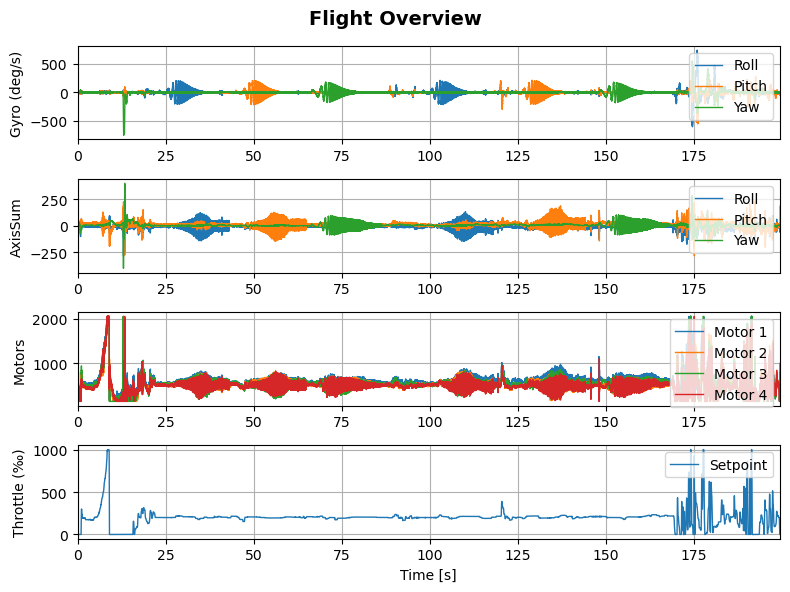

In [18]:
# Group 2: Custom labels for Overview Plot
group2 = [
    {
        'idx': df.ind.gyroUnfilt,
        'ylabel': 'Gyro (deg/s)',
        'legend': ['Roll', 'Pitch', 'Yaw']
    },
    {
        'idx': df.ind.axisSum,
        'ylabel': 'AxisSum',
        'legend': ['Roll', 'Pitch', 'Yaw']
    },
    {
        'idx': df.ind.motor,
        'ylabel': 'Motors',
        'legend': ['Motor 1', 'Motor 2', 'Motor 3', 'Motor 4']
    },
    {
        'idx': np.array([df.ind.setpoint[3]]),
        'ylabel': 'Throttle (\u2030)',
        'legend': ['Setpoint']
    }
]

plotter.plot_flight_data(df, group2, 'Flight Overview')

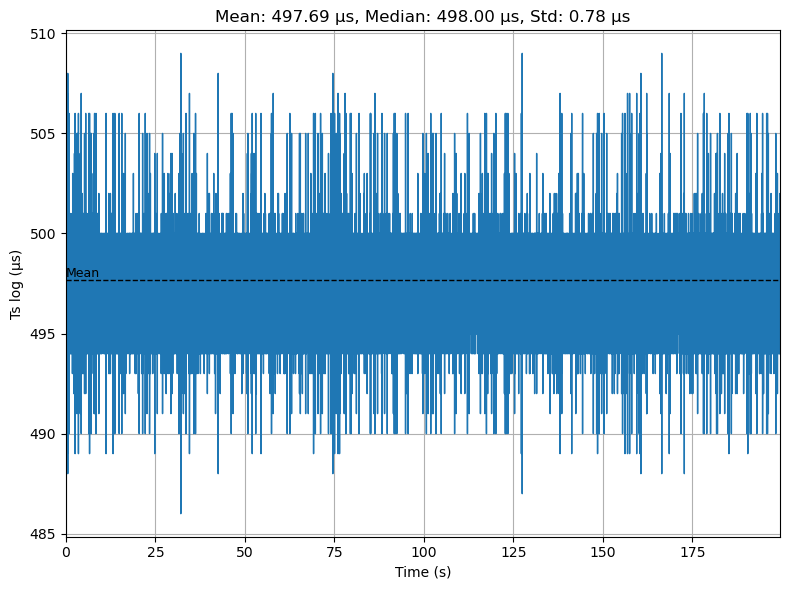

In [19]:
plotter.plot_eval_time(df.time)

## Transfer Function Estimation (Bode Plots)

In [20]:
print("="*70)
print("Transfer Function Estimation")
print("="*70)

# Initialize tuning objects
gyro_tuning = GyroCtrlTuning(df.data, df.ind, df.Ts_log, df.para, df.Ts_cntr)

# Calculate transfer functions
resolution_factor_tf = 2.0
overlap_tf = 0.9

print(f"\nCalculating transfer functions...")
print(f"  Window length: {resolution_factor_tf} s")
print(f"  Overlap: {overlap_tf*100}%")

gyro_tuning = gyro_tuning.calculate_transfer_func(resolution_factor_tf, overlap_tf)

Transfer Function Estimation

Calculating transfer functions...
  Window length: 2.0 s
  Overlap: 90.0%


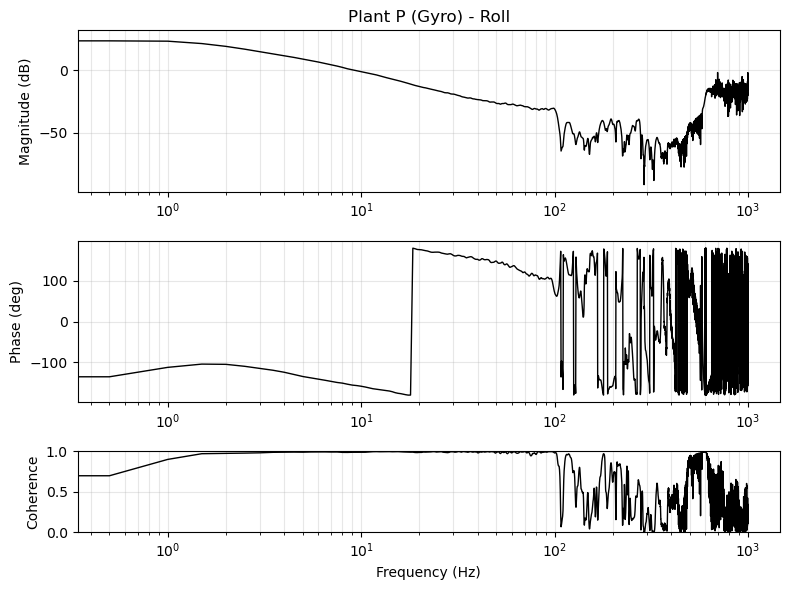

In [21]:
# Plot Bode diagrams
plotter.plot_bode_plant(gyro_tuning, roll, 'Gyro')

## Spectral Analysis

In [22]:
print("="*70)
print("Spectral Analysis")
print("="*70)

analysis_flight = FlightAnalyzer(df.data, df.ind, df.Ts_log)

# Calculate spectra
resolution_factor_spectra = 2.5
overlap_spectra = 0.9

print(f"\nCalculating spectra...")
print(f"  Window length: {resolution_factor_spectra} s")
print(f"  Overlap: {overlap_spectra*100}%")

analysis_flight = analysis_flight.calculate_spectra(
    resolution_factor_spectra,
    overlap_spectra
)

# Calculate spectrogram
resolution_factor_spectrogram = 0.2
overlap_spectrogram = 0.9

print(f"\nCalculating spectrogram...")
print(f"  Window length: {resolution_factor_spectrogram} s")
print(f"  Overlap: {overlap_spectrogram*100}%")

analysis_flight = analysis_flight.calculate_spectrogram(
    resolution_factor_spectrogram,
    overlap_spectrogram
)

Spectral Analysis

Calculating spectra...
  Window length: 2.5 s
  Overlap: 90.0%

Calculating spectrogram...
  Window length: 0.2 s
  Overlap: 90.0%


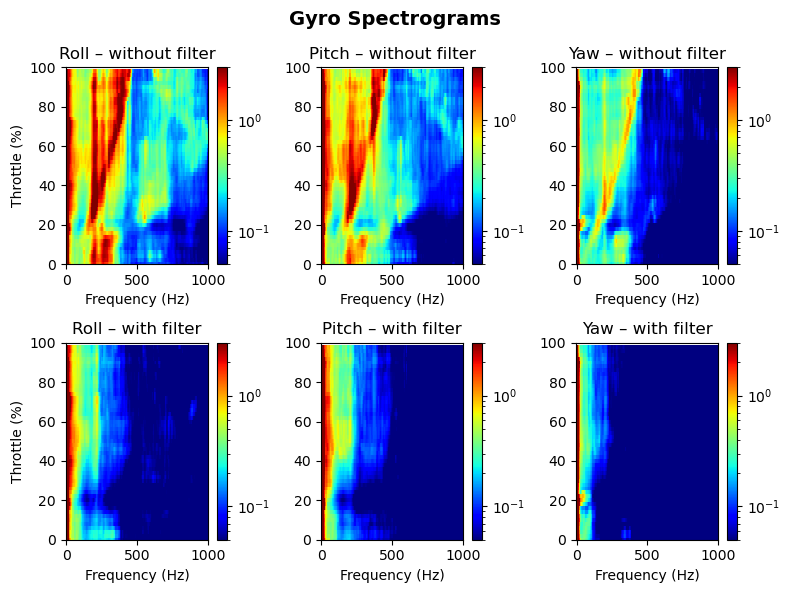

In [23]:
# Plot spectral analysis
plotter.plot_spectrogram(analysis_flight, 3)

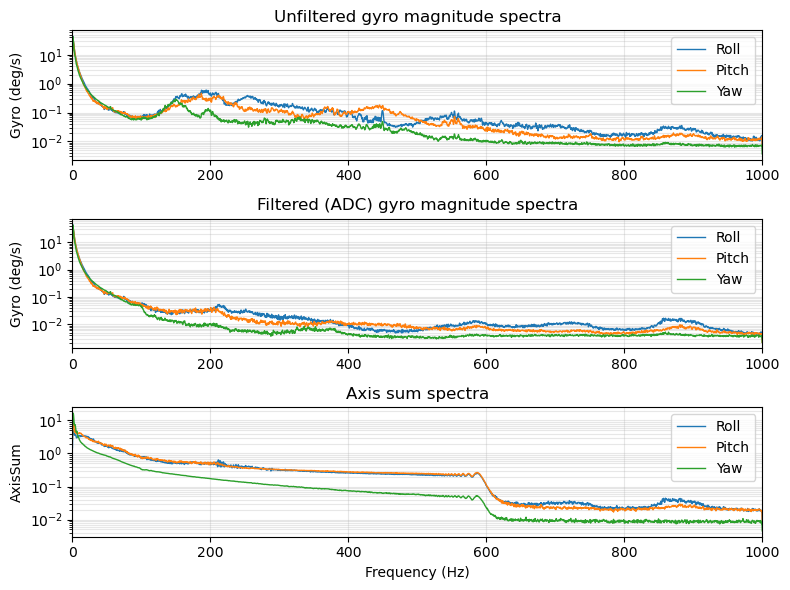

In [24]:
plotter.plot_gyro_spectra(analysis_flight)

## Controller Tuning

In [25]:
print("="*70)
print("Controller Tuning")
print("="*70)

# Axis selection:
# 0 = roll
# 1 = pitch
# 2 = yaw

ind_ax = 0

# I-term compensation
do_compensate_iterm = True

# Use default parameters
default_parameters = False

Controller Tuning


### Configure New Parameters


Tuning axis: Roll

   used PID parameters are:
      rollPID: [56, 92, 45]

   used filter parameters are:
      gyro_lpf: 0
      gyro_lowpass_hz: 0
      gyro_soft_type: 0
      gyro_lowpass_dyn_hz: 0
      gyro_lowpass2_hz: 800
      gyro_soft2_type: 0
      gyro_notch_hz: 0
      gyro_notch_cutoff: 0
      dterm_lpf_hz: 0
      dterm_filter_type: 0
      dterm_lpf_dyn_hz: 150
      dterm_lpf2_hz: 100
      dterm_filter2_type: 3
      dterm_notch_hz: 0
      dterm_notch_cutoff: 0
      yaw_lpf_hz: 200

   used fI is: 2.00 Hz

--------------------------------------------------

   new PID values (Betaflight format):
      p_roll = 60
      i_roll = 92
      d_roll = 50

   copy/paste into Betaflight CLI:
      set p_roll = 60
      set i_roll = 92
      set d_roll = 50
      save

   new parameters are:
      gyro_lpf: 0
      gyro_lowpass_hz: 0
      gyro_soft_type: 0
      gyro_lowpass_dyn_hz: 0
      gyro_lowpass2_hz: 800
      gyro_soft2_type: 0
      gyro_notch_hz: 0
      gyro

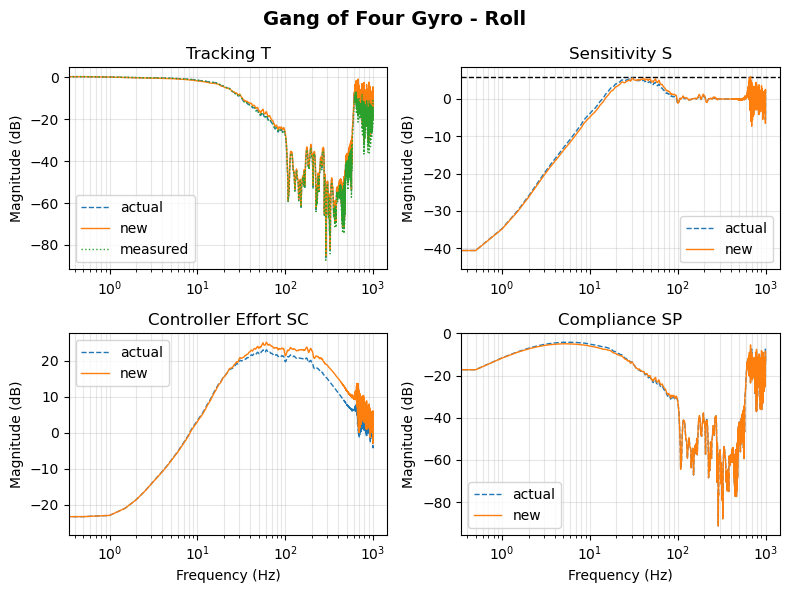

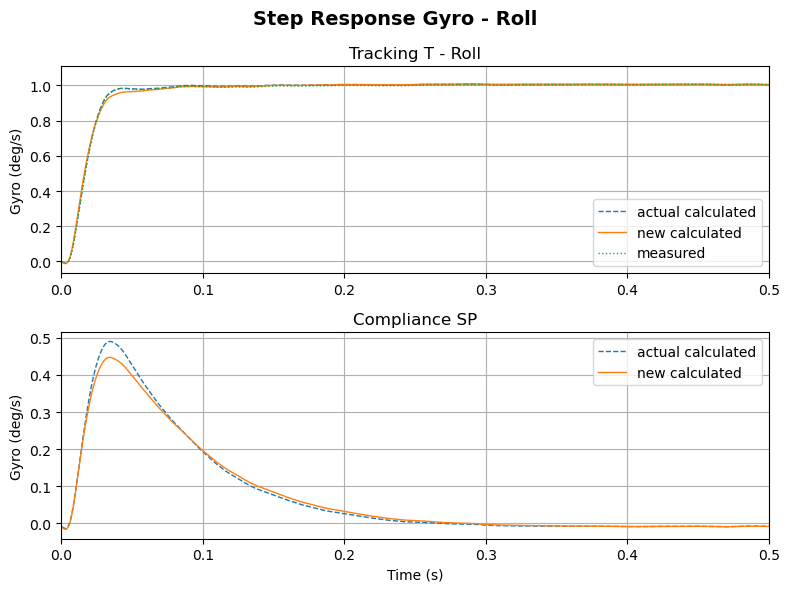

In [26]:
para_new = df.para.make_copy()

# Configure filters
para_new.data['gyro_lpf'] = '0'                 # frequency of static lpf
para_new.data['gyro_lowpass_hz'] = '0'          # frequency of gyro lpf 1
para_new.data['gyro_soft_type'] = '0'           # type of gyro lpf 1
para_new.data['gyro_lowpass_dyn_hz'] = '0,0'    # dyn gyro lpf (overwrites gyro_lowpass_hz)
para_new.data['gyro_lowpass2_hz'] = '800'       # frequency of gyro lpf 2
para_new.data['gyro_soft2_type'] = '0'          # type of gyro lpf 2
para_new.data['gyro_notch_hz'] = '0,0'          # gyro notch cutoff 1 and 2
para_new.data['gyro_notch_cutoff'] = '0,0'      # gyro notch 1 and 2

para_new.data['dterm_lpf_hz'] = '0'             # frequency of dterm lpf 1
para_new.data['dterm_filter_type'] = '0'        # type of dterm lpf 1
para_new.data['dterm_lpf_dyn_hz'] = '0,0'       # dyn dterm lpf (overwrites dterm_lpf_hz)
para_new.data['dterm_lpf2_hz'] = '120'          # frequency of dterm lpf 2
para_new.data['dterm_filter2_type'] = '3'       # type of dterm lpf 2
para_new.data['dterm_notch_hz'] = '0'           # frequency of dterm notch
para_new.data['dterm_notch_cutoff'] = '0'       # cutoff of dterm notch
para_new.data['yaw_lpf_hz'] = '200'             # frequency of yaw lpf (PT1)

# Configure PID gains based on axis
if ind_ax == 0:  # Roll
    P_new = 60
    I_new = 92
    D_new = 50
elif ind_ax == 1:  # Pitch
    P_new = 71
    I_new = 118
    D_new = 47
else:               # Yaw
    P_new = 35
    I_new = 70
    D_new = 1

print(f"\nTuning axis: {plotter.axis_names[ind_ax]}\n")

# Calculate new controller
gyro_tuning = gyro_tuning.calculate_new_controller(
    ind_ax, P_new, I_new, D_new, default_parameters, para_new
)

# Get tuning data
gyro_tuning = gyro_tuning.get_tuning_data(do_compensate_iterm)

# Plot results
plotter.plot_gang_of_four(gyro_tuning, 'Gyro')
plotter.plot_step_response(gyro_tuning, 'Gyro', 'Gyro (deg/s)')

---
**Analysis Complete!**